In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd drive

/content/drive


In [ ]:
cd My Drive

/content/drive/My Drive


In [ ]:
# loading the library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#loading the data
df = pd.read_csv('retail_store_inventory.csv')

In [ ]:
# display the top 5 rows
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [ ]:
# display the number of rows and columns
df.shape

(73100, 15)

In [ ]:
# display the basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [ ]:
# display the start and last date
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Date range: 2022-01-01 to 2024-01-01


In [ ]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# Create SKU identifier (Store + Product combination)
df['SKU'] = df['Store ID'].astype(str) + '_' + df['Product ID'].astype(str)


In [ ]:
# Sort data by SKU and Date
df = df.sort_values(['SKU', 'Date']).reset_index(drop=True)

In [ ]:
# Derive lead time (approximation: difference between units ordered and received)
df['Lead_Time_Days'] = np.random.normal(7, 2, len(df))  # Simulated lead time (replace with actual calculation)
df['Lead_Time_Days'] = np.clip(df['Lead_Time_Days'], 1, 30).astype(int)

In [ ]:
# Calculate stockout indicator
df['Stockout'] = (df['Inventory Level'] == 0).astype(int)

In [ ]:
# Calculate daily demand (units sold)
df['Daily_Demand'] = df['Units Sold']


In [ ]:
# display the statistical summary of the numerical column
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing,Lead_Time_Days,Stockout,Daily_Demand
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.0,73100.000000
mean,2023-01-01 00:00:00,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077,6.497004,0.0,136.464870
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000,1.000000,0.0,0.000000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000,5.000000,0.0,49.000000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000,7.000000,0.0,107.000000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000,8.000000,0.0,203.000000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000,14.000000,0.0,499.000000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408,2.017354,0.0,108.919406


In [ ]:
# display the summary of the object column
df.describe(include='object')

,Store ID,Product ID,Category,Region,Weather Condition,Seasonality,SKU
count,73100,73100,73100,73100,73100,73100,73100
unique,5,20,5,4,4,4,100
top,S001,P0001,Furniture,East,Sunny,Spring,S001_P0001
freq,14620,3655,14699,18349,18290,18317,731


In [ ]:
# SKU-level analysis
print("\n SKU-Level Analysis:")
sku_analysis = df.groupby('SKU').agg({
    'Units Sold': ['mean', 'std', 'sum'],
    'Inventory Level': ['mean', 'min', 'max'],
    'Units Ordered': ['mean', 'sum'],
    'Stockout': ['sum', 'mean'],
    'Price': 'mean',
    'Lead_Time_Days': 'mean'
}).round(2)
# Flatten column names
sku_analysis.columns = ['_'.join(col) for col in sku_analysis.columns]
sku_analysis = sku_analysis.reset_index()

print("Top 10 SKUs by total sales:")
top_skus = sku_analysis.sort_values('Units Sold_sum', ascending=False).head(10)
print(top_skus[['SKU', 'Units Sold_sum', 'Stockout_mean', 'Inventory Level_mean']])

# Stockout analysis
print(f"\nOverall stockout rate: {df['Stockout'].mean():.2%}")
print(f"SKUs with stockout rate > 10%: {(sku_analysis['Stockout_mean'] > 0.1).sum()}")


 SKU-Level Analysis:
Top 10 SKUs by total sales:
           SKU  Units Sold_sum  Stockout_mean  Inventory Level_mean
94  S005_P0015          109099            0.0                277.91
52  S003_P0013          107479            0.0                285.26
20  S002_P0001          105999            0.0                278.34
82  S005_P0003          105667            0.0                283.99
44  S003_P0005          105408            0.0                277.57
28  S002_P0009          105376            0.0                282.95
39  S002_P0020          105343            0.0                276.31
53  S003_P0014          105188            0.0                290.87
75  S004_P0016          104777            0.0                280.27
56  S003_P0017          104566            0.0                277.15

Overall stockout rate: 0.00%
SKUs with stockout rate > 10%: 0


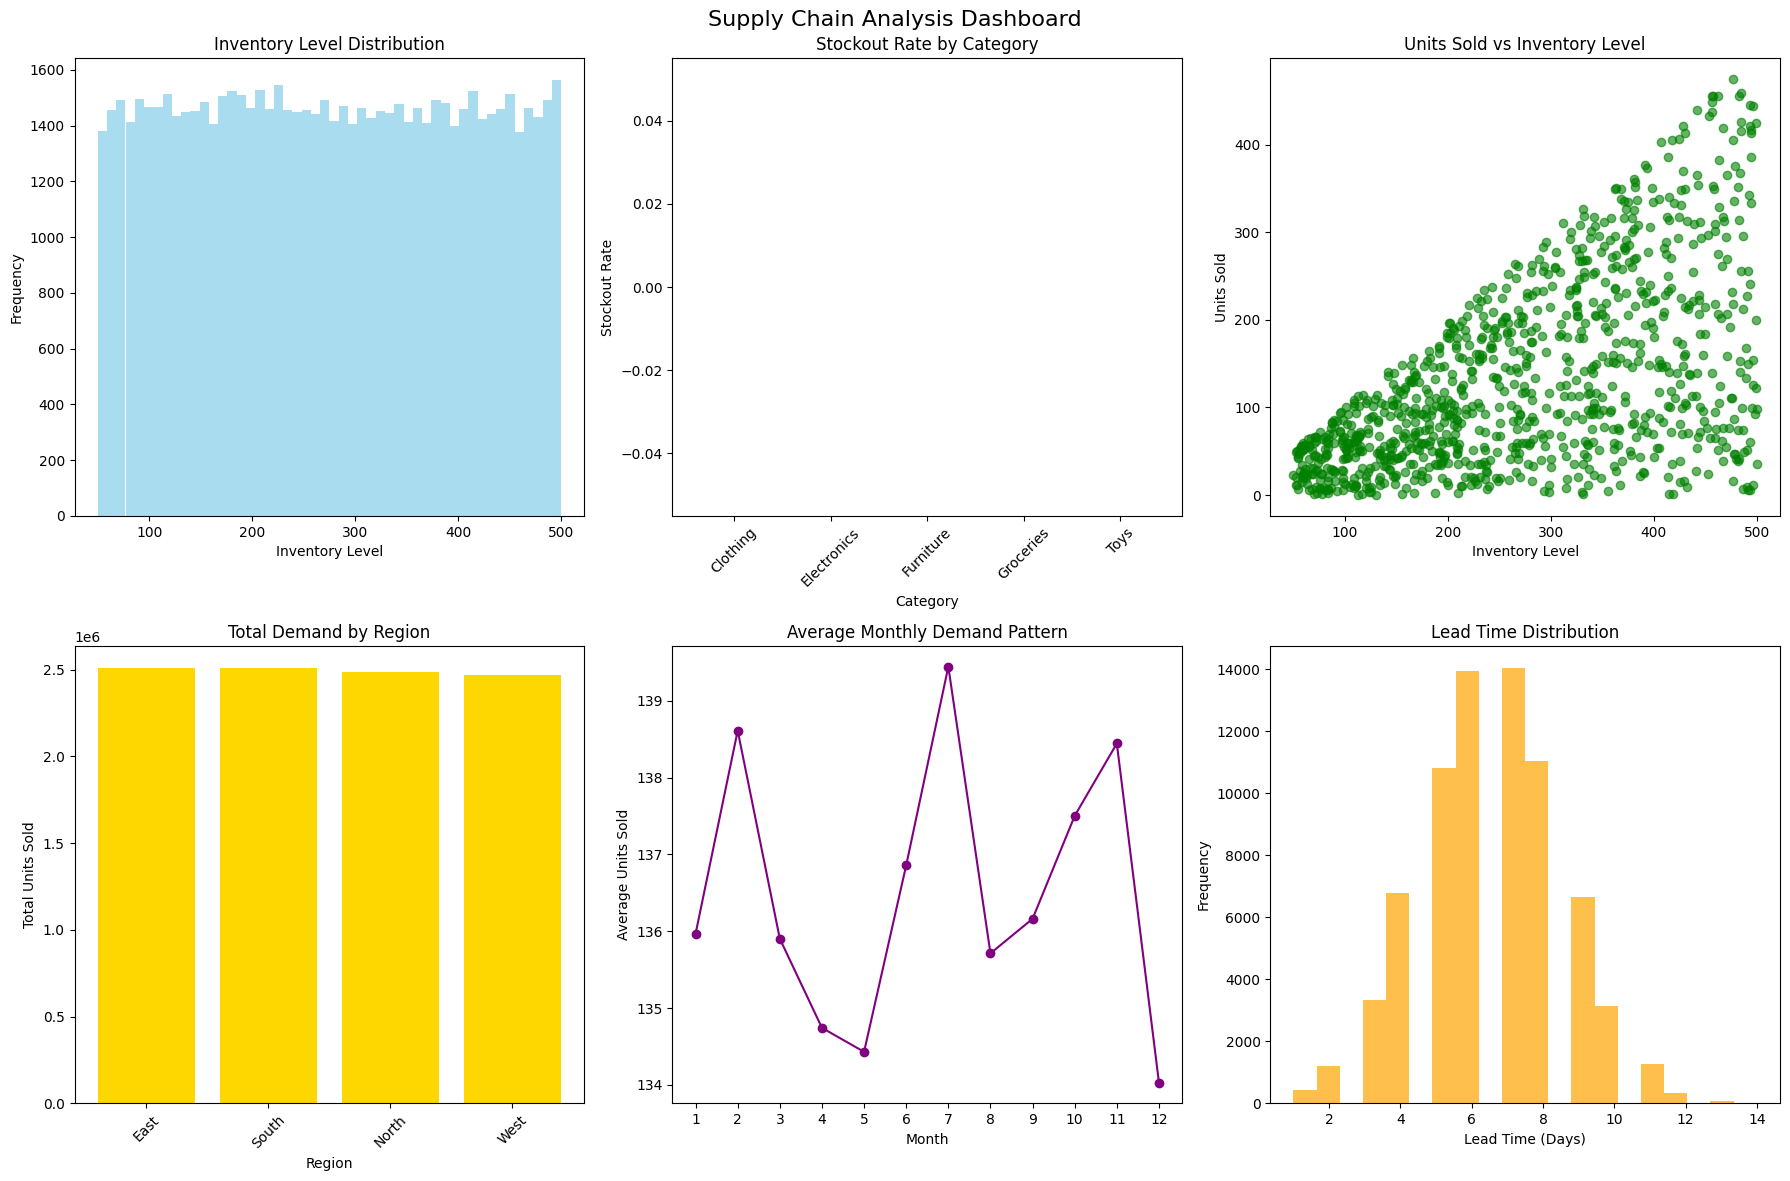

In [ ]:
# Set up the plotting style
plt.rcParams['figure.figsize'] = (15, 10)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Supply Chain Analysis Dashboard', fontsize=16)

# Inventory Level Distribution
axes[0,0].hist(df['Inventory Level'], bins=50, alpha=0.7, color='skyblue')
axes[0,0].set_title('Inventory Level Distribution')
axes[0,0].set_xlabel('Inventory Level')
axes[0,0].set_ylabel('Frequency')

# Stockout Rate by Category
stockout_by_category = df.groupby('Category')['Stockout'].mean().sort_values(ascending=False)
axes[0,1].bar(stockout_by_category.index, stockout_by_category.values, color='coral')
axes[0,1].set_title('Stockout Rate by Category')
axes[0,1].set_xlabel('Category')
axes[0,1].set_ylabel('Stockout Rate')
axes[0,1].tick_params(axis='x', rotation=45)

# Units Sold vs Inventory Level
sample_data = df.sample(1000)  # Sample for better visualization
axes[0,2].scatter(sample_data['Inventory Level'], sample_data['Units Sold'], alpha=0.6, color='green')
axes[0,2].set_title('Units Sold vs Inventory Level')
axes[0,2].set_xlabel('Inventory Level')
axes[0,2].set_ylabel('Units Sold')

# Demand by Region
demand_by_region = df.groupby('Region')['Units Sold'].sum().sort_values(ascending=False)
axes[1,0].bar(demand_by_region.index, demand_by_region.values, color='gold')
axes[1,0].set_title('Total Demand by Region')
axes[1,0].set_xlabel('Region')
axes[1,0].set_ylabel('Total Units Sold')
axes[1,0].tick_params(axis='x', rotation=45)

# Seasonal Demand Pattern
df['Month'] = df['Date'].dt.month
monthly_demand = df.groupby('Month')['Units Sold'].mean()
axes[1,1].plot(monthly_demand.index, monthly_demand.values, marker='o', color='purple')
axes[1,1].set_title('Average Monthly Demand Pattern')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Average Units Sold')
axes[1,1].set_xticks(range(1, 13))

# Lead Time Distribution
axes[1,2].hist(df['Lead_Time_Days'], bins=20, alpha=0.7, color='orange')
axes[1,2].set_title('Lead Time Distribution')
axes[1,2].set_xlabel('Lead Time (Days)')
axes[1,2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
# Select top SKU
top_sku = sku_analysis.sort_values('Units Sold_sum', ascending=False).iloc[0]['SKU']
print(f"Analyzing top SKU: {top_sku}")

Analyzing top SKU: S005_P0015


In [ ]:
# Prepare time series data for top SKU
ts_data = df[df['SKU'] == top_sku].copy()
ts_data = ts_data.set_index('Date')['Units Sold'].resample('D').sum().fillna(0)

print(f"Time series length: {len(ts_data)} days")

Time series length: 731 days


In [ ]:
# Split data for training and testing
train_size = int(len(ts_data) * 0.8)
train_data = ts_data[:train_size]
test_data = ts_data[train_size:]

print(f"Training data: {len(train_data)} days")
print(f"Testing data: {len(test_data)} days")



Training data: 584 days
Testing data: 147 days


In [ ]:
# Calculate forecast accuracy
def calculate_metrics(actual, forecast):
    mae = np.mean(np.abs(actual - forecast))
    mse = np.mean((actual - forecast) ** 2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual - forecast) / np.where(actual == 0, 1, actual))) * 100
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

In [ ]:
# Check for stationarity
def check_stationarity(timeseries):
    result = adfuller(timeseries.dropna())
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    if result[1] <= 0.05:
        print("Series is stationary")
        return True
    else:
        print("Series is non-stationary")
        return False

is_stationary = check_stationarity(train_data)

# Make series stationary if needed
if not is_stationary:
    print("Applying first differencing...")
    train_data_diff = train_data.diff().dropna()
    is_stationary_diff = check_stationarity(train_data_diff)
    d = 1
else:
    d = 0

ADF Statistic: -18.490137
p-value: 0.000000
Series is stationary


In [ ]:
# Auto ARIMA parameter selection (simple approach)
def find_best_arima_params(data, max_p=3, max_q=3):
    best_aic = float('inf')
    best_params = None

    print("Finding best ARIMA parameters...")
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            try:
                model = ARIMA(data, order=(p, d, q))
                fitted_model = model.fit()
                if fitted_model.aic < best_aic:
                    best_aic = fitted_model.aic
                    best_params = (p, d, q)
            except:
                continue

    return best_params, best_aic


In [ ]:
# Find best parameters
best_params, best_aic = find_best_arima_params(train_data)
print(f"Best ARIMA parameters: {best_params} with AIC: {best_aic:.2f}")




Finding best ARIMA parameters...
Best ARIMA parameters: (0, 0, 0) with AIC: 7220.67


In [ ]:
# Fit ARIMA model
arima_model = ARIMA(train_data, order=best_params)
arima_fitted = arima_model.fit()
print(arima_fitted.summary())

# Make ARIMA predictions
arima_forecast = arima_fitted.forecast(steps=len(test_data))
arima_metrics = calculate_metrics(test_data.values, arima_forecast)

print(f"\nARIMA Forecast Metrics:")
for metric, value in arima_metrics.items():
    print(f"{metric}: {value:.2f}")

                               SARIMAX Results                                
Dep. Variable:             Units Sold   No. Observations:                  584
Model:                          ARIMA   Log Likelihood               -3608.335
Date:                Sun, 24 Aug 2025   AIC                           7220.670
Time:                        16:42:07   BIC                           7229.410
Sample:                    01-01-2022   HQIC                          7224.076
                         - 08-07-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        151.1507      5.756     26.262      0.000     139.870     162.431
sigma2      1.363e+04   1204.964     11.308      0.000    1.13e+04     1.6e+04
Ljung-Box (L1) (Q):                   0.73   Jarque-

In [ ]:
from prophet import Prophet

In [ ]:
print("\n Prophet Forecasting:")

prophet_forecast = None
prophet_metrics = None


# Prepare data for Prophet (requires 'ds' and 'y' columns)
prophet_train = pd.DataFrame({
        'ds': train_data.index,
        'y': train_data.values
    })

# Create and fit Prophet model
prophet_model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
        changepoint_prior_scale=0.05
    )

prophet_model.fit(prophet_train)

# Create future dataframe for predictions
future_dates = pd.DataFrame({'ds': test_data.index})
prophet_forecast = prophet_model.predict(future_dates)
prophet_predictions = prophet_forecast['yhat'].values
prophet_metrics = calculate_metrics(test_data.values, prophet_predictions)

print(f"\nProphet Forecast Metrics:")
for metric, value in prophet_metrics.items():
  print(f"{metric}: {value:.2f}")

# Prophet components
print("\nProphet detected components:")
if hasattr(prophet_model, 'seasonalities'):
  for seasonality in prophet_model.seasonalities:
    print(f"- {seasonality}")




DEBUG:cmdstanpy:input tempfile: /tmp/tmp998p09l5/lmpx24fe.json



 Prophet Forecasting:


DEBUG:cmdstanpy:input tempfile: /tmp/tmp998p09l5/bh3ei_w1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=41403', 'data', 'file=/tmp/tmp998p09l5/lmpx24fe.json', 'init=/tmp/tmp998p09l5/bh3ei_w1.json', 'output', 'file=/tmp/tmp998p09l5/prophet_modelwoqnsa73/prophet_model-20250824164711.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:47:11 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:47:11 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



Prophet Forecast Metrics:
MAE: 88.92
MSE: 12287.37
RMSE: 110.85
MAPE: 205.47

Prophet detected components:
- yearly
- weekly
- daily



 Model Comparison:


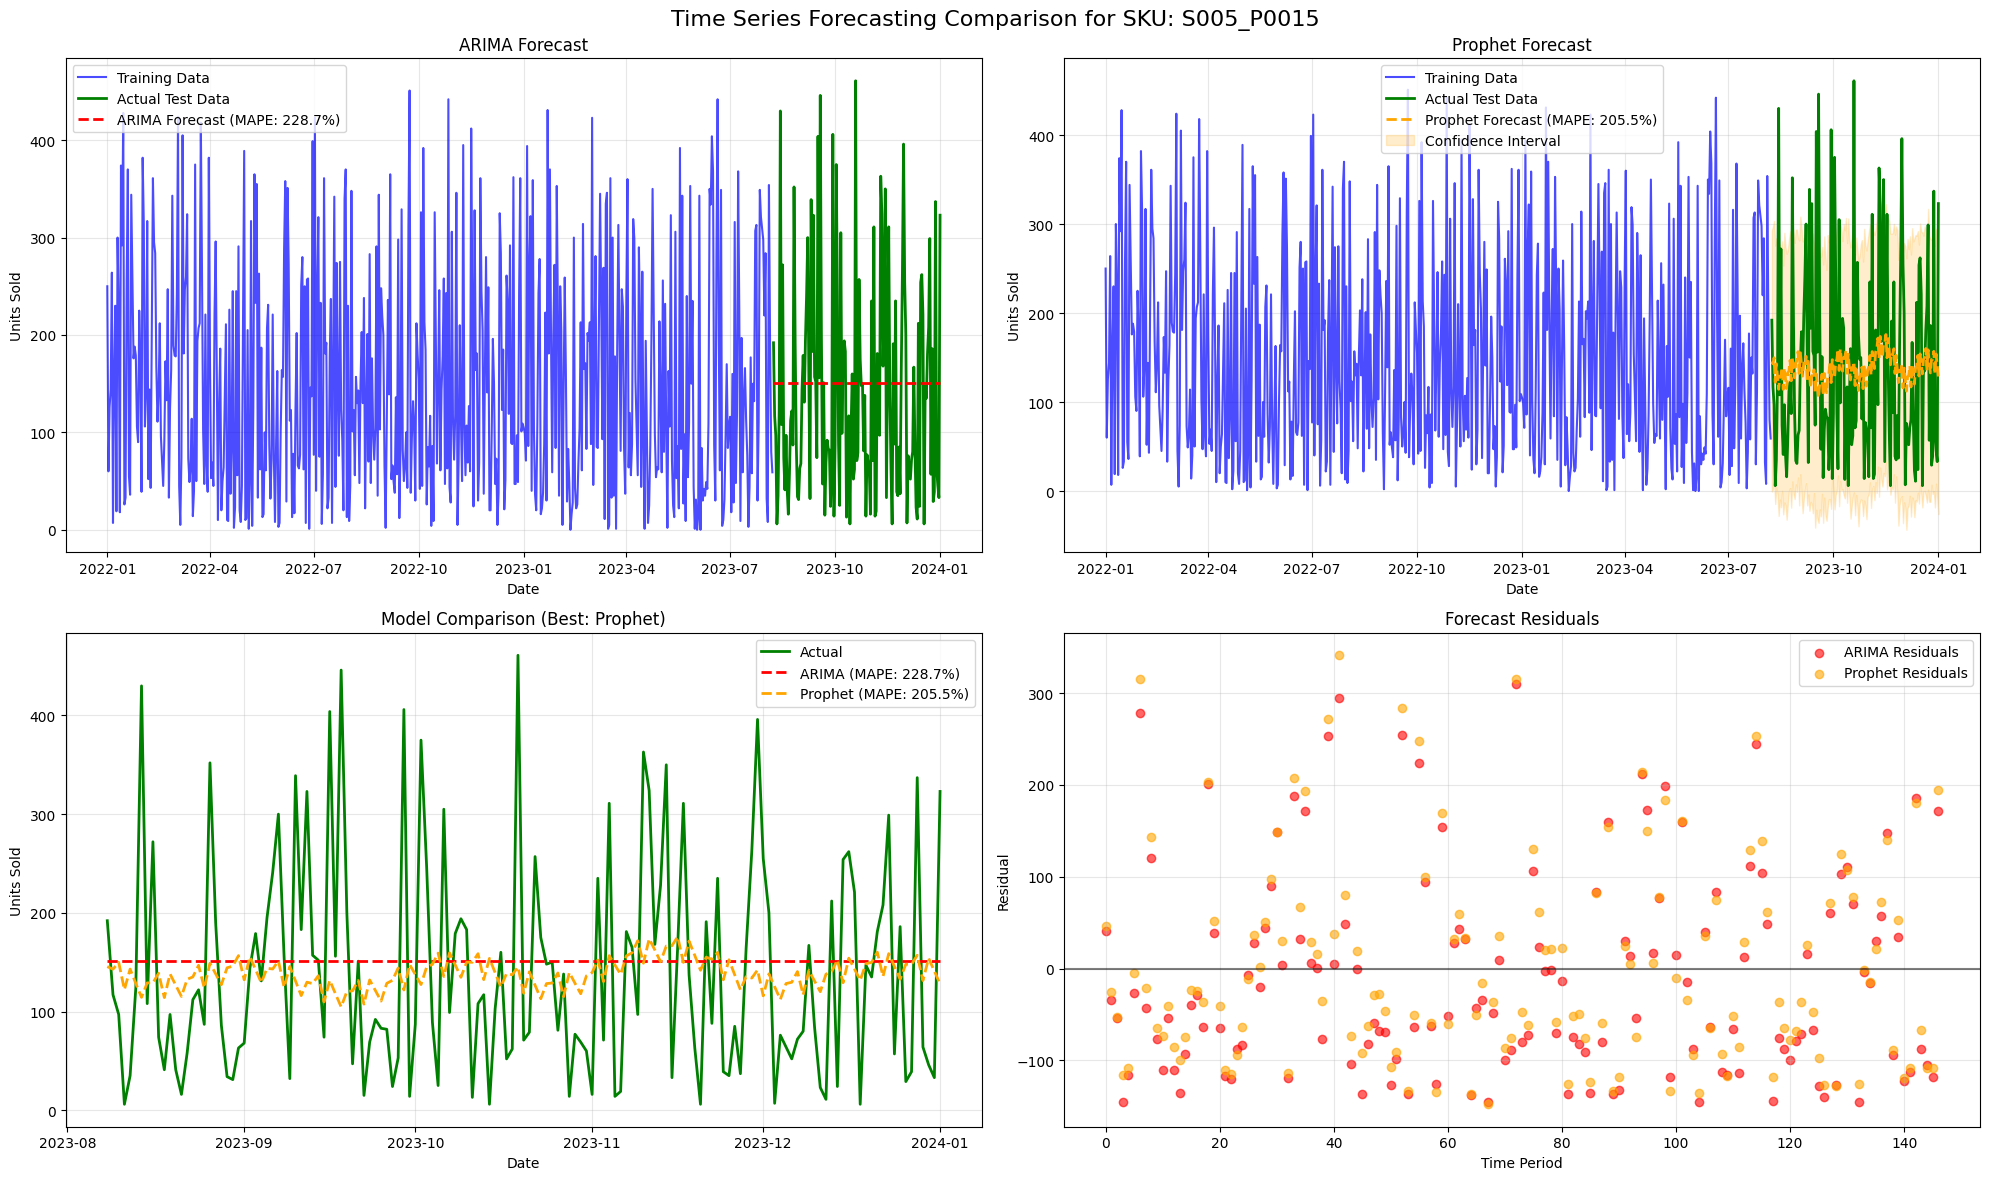

In [ ]:
print("\n Model Comparison:")

# Create comprehensive forecast comparison plot
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle(f'Time Series Forecasting Comparison for SKU: {top_sku}', fontsize=16)

# Plot 1: ARIMA Forecast
axes[0,0].plot(train_data.index, train_data.values, label='Training Data', color='blue', alpha=0.7)
axes[0,0].plot(test_data.index, test_data.values, label='Actual Test Data', color='green', linewidth=2)
axes[0,0].plot(test_data.index, arima_forecast, label=f'ARIMA Forecast (MAPE: {arima_metrics["MAPE"]:.1f}%)',
               color='red', linestyle='--', linewidth=2)
axes[0,0].set_title('ARIMA Forecast')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Units Sold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Prophet Forecast (if available)
if prophet_forecast is not None:
    axes[0,1].plot(train_data.index, train_data.values, label='Training Data', color='blue', alpha=0.7)
    axes[0,1].plot(test_data.index, test_data.values, label='Actual Test Data', color='green', linewidth=2)
    axes[0,1].plot(test_data.index, prophet_predictions, label=f'Prophet Forecast (MAPE: {prophet_metrics["MAPE"]:.1f}%)',
                   color='orange', linestyle='--', linewidth=2)

    # Add confidence intervals
    axes[0,1].fill_between(test_data.index,
                          prophet_forecast['yhat_lower'],
                          prophet_forecast['yhat_upper'],
                          color='orange', alpha=0.2, label='Confidence Interval')

    axes[0,1].set_title('Prophet Forecast')
    axes[0,1].set_xlabel('Date')
    axes[0,1].set_ylabel('Units Sold')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

# Plot 3: Model Comparison
if prophet_forecast is not None:
    axes[1,0].plot(test_data.index, test_data.values, label='Actual', color='green', linewidth=2)
    axes[1,0].plot(test_data.index, arima_forecast, label=f'ARIMA (MAPE: {arima_metrics["MAPE"]:.1f}%)',
                   color='red', linestyle='--', linewidth=2)
    axes[1,0].plot(test_data.index, prophet_predictions, label=f'Prophet (MAPE: {prophet_metrics["MAPE"]:.1f}%)',
                   color='orange', linestyle='--', linewidth=2)

    best_model = 'ARIMA' if arima_metrics['MAPE'] < prophet_metrics['MAPE'] else 'Prophet'
    axes[1,0].set_title(f'Model Comparison (Best: {best_model})')
else:
    axes[1,0].plot(test_data.index, test_data.values, label='Actual', color='green', linewidth=2)
    axes[1,0].plot(test_data.index, arima_forecast, label=f'ARIMA (MAPE: {arima_metrics["MAPE"]:.1f}%)',
                   color='red', linestyle='--', linewidth=2)
    axes[1,0].set_title('ARIMA Forecast Only')

axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Units Sold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Residuals Analysis
residuals_arima = test_data.values - arima_forecast
axes[1,1].scatter(range(len(residuals_arima)), residuals_arima, alpha=0.6, color='red', label='ARIMA Residuals')

if prophet_forecast is not None:
    residuals_prophet = test_data.values - prophet_predictions
    axes[1,1].scatter(range(len(residuals_prophet)), residuals_prophet, alpha=0.6, color='orange', label='Prophet Residuals')

axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[1,1].set_title('Forecast Residuals')
axes[1,1].set_xlabel('Time Period')
axes[1,1].set_ylabel('Residual')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()

In [ ]:
# Summary of forecast performance
print(f"\n  FORECASTING SUMMARY ")
print(f"ARIMA Model: MAPE = {arima_metrics['MAPE']:.2f}%, RMSE = {arima_metrics['RMSE']:.2f}")
if prophet_forecast is not None:
    print(f"Prophet Model: MAPE = {prophet_metrics['MAPE']:.2f}%, RMSE = {prophet_metrics['RMSE']:.2f}")

    if arima_metrics['MAPE'] < prophet_metrics['MAPE']:
        print("ARIMA performs better for this SKU")
        chosen_forecast = arima_forecast
    else:
        print("Prophet performs better for this SKU")
        chosen_forecast = prophet_predictions
else:
    print("Using ARIMA model (Prophet not available)")
    chosen_forecast = arima_forecast


  FORECASTING SUMMARY 
ARIMA Model: MAPE = 228.66%, RMSE = 111.15
Prophet Model: MAPE = 205.47%, RMSE = 110.85
Prophet performs better for this SKU


In [ ]:
print("\n SAFETY STOCK CALCULATION ===")


 SAFETY STOCK CALCULATION ===


In [ ]:


# Calculate safety stock for each SKU
def calculate_safety_stock(demand_mean, demand_std, lead_time_mean, service_level=0.95):
    """
    Calculate safety stock using the formula:
    Safety Stock = Z * sqrt(Lead Time) * Demand Std Dev
    Where Z is the service level factor (1.65 for 95% service level)
    """
    z_score = 1.65 if service_level == 0.95 else 1.28  # 95% or 90% service level
    safety_stock = z_score * np.sqrt(lead_time_mean) * demand_std
    return max(0, safety_stock)  # Ensure non-negative

In [ ]:
def calculate_reorder_point(demand_mean, lead_time_mean, safety_stock):
    """
    Calculate reorder point:
    Reorder Point = (Average Demand * Lead Time) + Safety Stock
    """
    return (demand_mean * lead_time_mean) + safety_stock



In [ ]:
# Apply calculations to each SKU
sku_inventory_params = []

for sku in sku_analysis['SKU'].unique():
    sku_data = df[df['SKU'] == sku]

    demand_mean = sku_data['Units Sold'].mean()
    demand_std = sku_data['Units Sold'].std()
    lead_time_mean = sku_data['Lead_Time_Days'].mean()
    current_avg_inventory = sku_data['Inventory Level'].mean()
    stockout_rate = sku_data['Stockout'].mean()

    # Calculate safety stock for 95% service level
    safety_stock_95 = calculate_safety_stock(demand_mean, demand_std, lead_time_mean, 0.95)
    safety_stock_90 = calculate_safety_stock(demand_mean, demand_std, lead_time_mean, 0.90)

    # Calculate reorder points
    reorder_point_95 = calculate_reorder_point(demand_mean, lead_time_mean, safety_stock_95)
    reorder_point_90 = calculate_reorder_point(demand_mean, lead_time_mean, safety_stock_90)

    sku_inventory_params.append({
        'SKU': sku,
        'Avg_Demand': demand_mean,
        'Demand_Std': demand_std,
        'Avg_Lead_Time': lead_time_mean,
        'Current_Avg_Inventory': current_avg_inventory,
        'Stockout_Rate': stockout_rate,
        'Safety_Stock_95': safety_stock_95,
        'Safety_Stock_90': safety_stock_90,
        'Reorder_Point_95': reorder_point_95,
        'Reorder_Point_90': reorder_point_90
    })

inventory_params_df = pd.DataFrame(sku_inventory_params)

print("\nInventory Parameters for Top 10 SKUs by Demand:")
top_10_params = inventory_params_df.sort_values('Avg_Demand', ascending=False).head(10)
print(top_10_params[['SKU', 'Avg_Demand', 'Current_Avg_Inventory', 'Safety_Stock_95', 'Reorder_Point_95', 'Stockout_Rate']].round(2))


Inventory Parameters for Top 10 SKUs by Demand:
           SKU  Avg_Demand  Current_Avg_Inventory  Safety_Stock_95  \
94  S005_P0015      149.25                 277.91           485.78   
52  S003_P0013      147.03                 285.26           476.69   
20  S002_P0001      145.01                 278.34           480.95   
82  S005_P0003      144.55                 283.99           473.33   
44  S003_P0005      144.20                 277.57           461.63   
28  S002_P0009      144.15                 282.95           471.05   
39  S002_P0020      144.11                 276.31           482.34   
53  S003_P0014      143.90                 290.87           473.07   
75  S004_P0016      143.33                 280.27           453.36   
56  S003_P0017      143.05                 277.15           455.74   

    Reorder_Point_95  Stockout_Rate  
94           1452.51            0.0  
52           1444.56            0.0  
20           1436.09            0.0  
82           1422.90        

In [ ]:
print("\n REORDER STRATEGY SIMULATION")

def simulate_inventory_policy(demand_data, initial_inventory, reorder_point, order_quantity, lead_time):
    """
    Simulate inventory levels with a reorder policy
    """
    inventory_levels = [initial_inventory]
    orders_placed = []
    stockouts = []

    pending_orders = []  # List of (arrival_day, quantity) tuples

    for day in range(len(demand_data)):
        current_inventory = inventory_levels[-1]
        daily_demand = demand_data[day]

        # Check if any pending orders arrive today
        arriving_orders = [order for order in pending_orders if order[0] == day]
        for order in arriving_orders:
            current_inventory += order[1]
            pending_orders.remove(order)

        # Meet demand
        units_sold = min(daily_demand, current_inventory)
        current_inventory -= units_sold

        # Check for stockout
        stockout = 1 if daily_demand > units_sold else 0
        stockouts.append(stockout)

        # Check if reorder is needed
        if current_inventory <= reorder_point:
            # Place order (arrives after lead_time days)
            arrival_day = day + lead_time
            pending_orders.append((arrival_day, order_quantity))
            orders_placed.append((day, order_quantity))

        inventory_levels.append(current_inventory)

    return inventory_levels[:-1], stockouts, orders_placed

# Simulate for top SKU
top_sku_data = df[df['SKU'] == top_sku]
demand_series = top_sku_data['Units Sold'].values
current_params = inventory_params_df[inventory_params_df['SKU'] == top_sku].iloc[0]

# Simulation parameters
initial_inventory = int(current_params['Current_Avg_Inventory'])
reorder_point = int(current_params['Reorder_Point_95'])
order_quantity = int(current_params['Avg_Demand'] * 14)  # 2 weeks of demand
lead_time = int(current_params['Avg_Lead_Time'])

print(f"\nSimulation Parameters for {top_sku}:")
print(f"Initial Inventory: {initial_inventory}")
print(f"Reorder Point: {reorder_point}")
print(f"Order Quantity: {order_quantity}")
print(f"Lead Time: {lead_time} days")

# Run simulation
inventory_sim, stockouts_sim, orders_sim = simulate_inventory_policy(
    demand_series[:100],  # Simulate first 100 days
    initial_inventory,
    reorder_point,
    order_quantity,
    lead_time
)




 REORDER STRATEGY SIMULATION

Simulation Parameters for S005_P0015:
Initial Inventory: 277
Reorder Point: 1452
Order Quantity: 2089
Lead Time: 6 days


In [ ]:
# Calculate simulation results
simulated_stockout_rate = np.mean(stockouts_sim)
avg_inventory_sim = np.mean(inventory_sim)
total_orders = len(orders_sim)

print(f"\nSimulation Results:")
print(f"Simulated Stockout Rate: {simulated_stockout_rate:.2%}")
print(f"Average Inventory Level: {avg_inventory_sim:.1f}")
print(f"Total Orders Placed: {total_orders}")
print(f"Original Stockout Rate: {current_params['Stockout_Rate']:.2%}")


Simulation Results:
Simulated Stockout Rate: 5.00%
Average Inventory Level: 6437.8
Total Orders Placed: 12
Original Stockout Rate: 0.00%


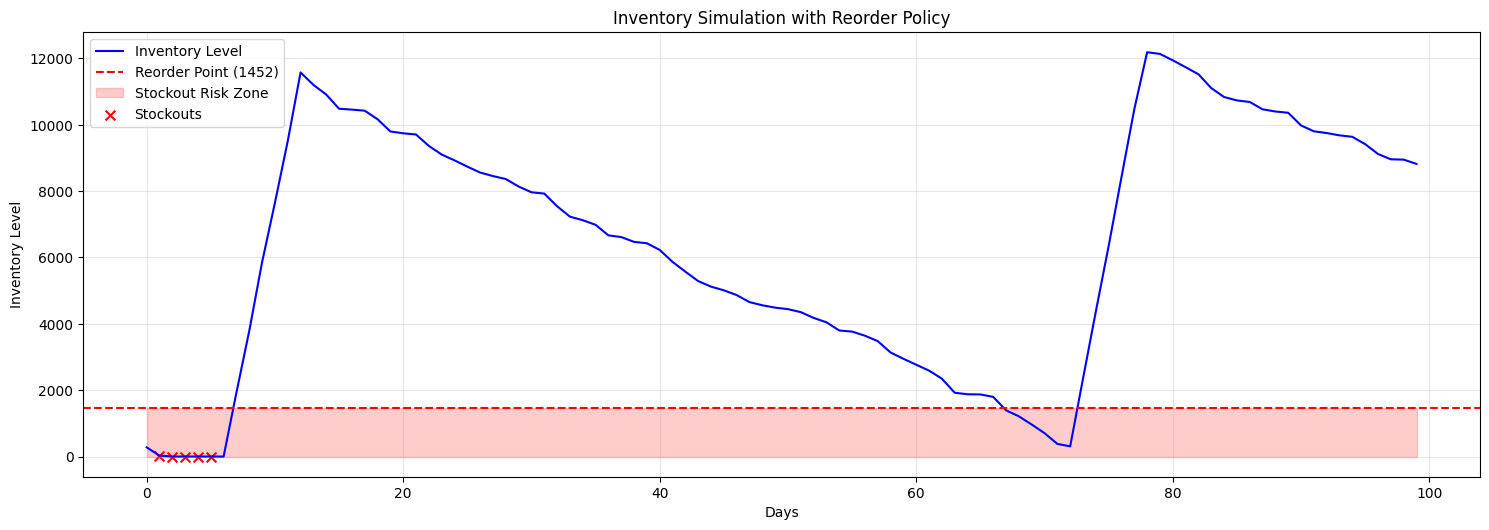

In [ ]:
# Plot simulation results
plt.subplot(2, 1, 2)
days = range(len(inventory_sim))
plt.plot(days, inventory_sim, label='Inventory Level', color='blue')
plt.axhline(y=reorder_point, color='red', linestyle='--', label=f'Reorder Point ({reorder_point})')
plt.fill_between(days, 0, [reorder_point]*len(days), alpha=0.2, color='red', label='Stockout Risk Zone')

# Mark stockouts
stockout_days = [i for i, x in enumerate(stockouts_sim) if x == 1]
if stockout_days:
    plt.scatter(stockout_days, [inventory_sim[i] for i in stockout_days],
               color='red', s=50, marker='x', label='Stockouts')

plt.title('Inventory Simulation with Reorder Policy')
plt.xlabel('Days')
plt.ylabel('Inventory Level')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\n SUMMARY & RECOMMENDATIONS ")

print("\nKEY FINDINGS:")
print(f"• Overall stockout rate: {df['Stockout'].mean():.2%}")
print(f"• Number of unique SKUs: {df['SKU'].nunique():,}")
print(f"• Average lead time: {df['Lead_Time_Days'].mean():.1f} days")
print(f"• SKUs with high stockout risk (>10%): {(sku_analysis['Stockout_mean'] > 0.1).sum()}")

print("\nRECOMMENDations:")
print("1. IMMEDIATE ACTIONS:")
print("   • Focus on SKUs with stockout rates > 10%")
print("   • Implement suggested reorder points for top-moving SKUs")
print("   • Review and optimize lead times with suppliers")

print("\n2. INVENTORY OPTIMIZATION:")
print("   • Use 95% service level safety stock for critical SKUs")
print("   • Use 90% service level for non-critical SKUs to reduce holding costs")
print("   • Implement automated reorder point system")

print("\n3. FORECASTING IMPROVEMENTS:")
print("   • Use ARIMA for stationary demand patterns")
print("   • Use Prophet for data with strong seasonality and trends")
print("   • Update forecasts regularly based on recent performance")
print("   • Consider ensemble methods combining ARIMA and Prophet")

print("\n4. MONITORING KPIs:")
print("   • Service Level: Target > 95% for critical SKUs")
print("   • Inventory Turnover: Monitor for optimal levels")
print("   • Stockout Frequency: Aim for < 5% overall")
print("   • Lead Time Variability: Work with suppliers to reduce")




 SUMMARY & RECOMMENDATIONS 

KEY FINDINGS:
• Overall stockout rate: 0.00%
• Number of unique SKUs: 100
• Average lead time: 6.5 days
• SKUs with high stockout risk (>10%): 0

RECOMMENDations:
1. IMMEDIATE ACTIONS:
   • Focus on SKUs with stockout rates > 10%
   • Implement suggested reorder points for top-moving SKUs
   • Review and optimize lead times with suppliers

2. INVENTORY OPTIMIZATION:
   • Use 95% service level safety stock for critical SKUs
   • Use 90% service level for non-critical SKUs to reduce holding costs
   • Implement automated reorder point system

3. FORECASTING IMPROVEMENTS:
   • Use ARIMA for stationary demand patterns
   • Use Prophet for data with strong seasonality and trends
   • Update forecasts regularly based on recent performance
   • Consider ensemble methods combining ARIMA and Prophet

4. MONITORING KPIs:
   • Service Level: Target > 95% for critical SKUs
   • Inventory Turnover: Monitor for optimal levels
   • Stockout Frequency: Aim for < 5% overal